# Exercise 1
**Các phép toán trên vector, ma trận và cosine similarity**


Trong phần này ta sẽ lần lượt xây dựng các phép toán cơ bản trên vector và matrix, sau đó dùng chúng để tính cosine similarity giữa hai vector
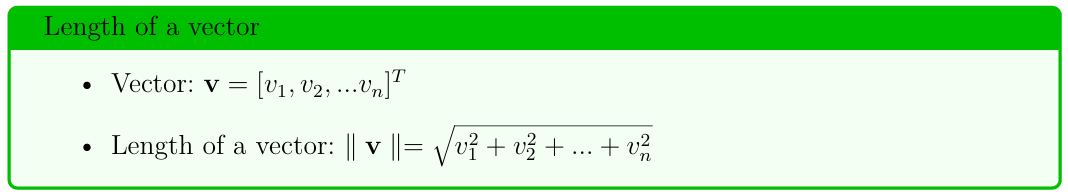

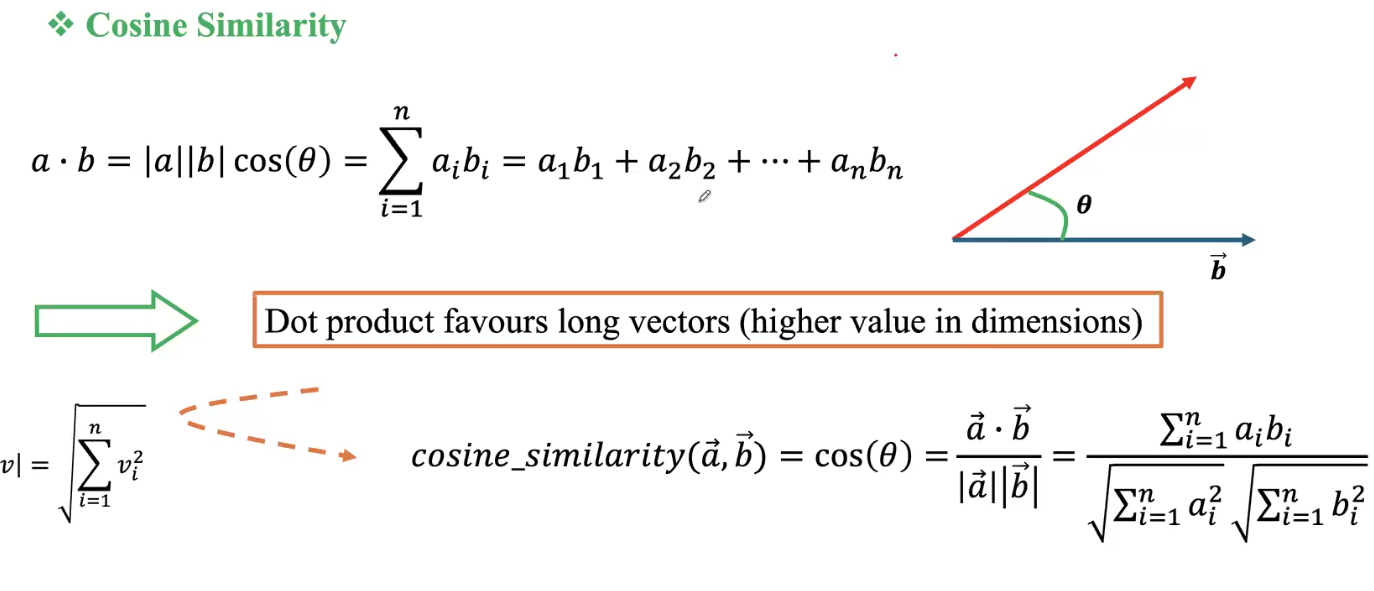

In [56]:
import numpy as np

def compute_vector_length(vector):
  norm = np.sqrt(np.sum(vector**2))

  return norm

vector = np.array([-2, 4, 9, 21])
result = compute_vector_length(vector)
print(round(result, 2))


23.28


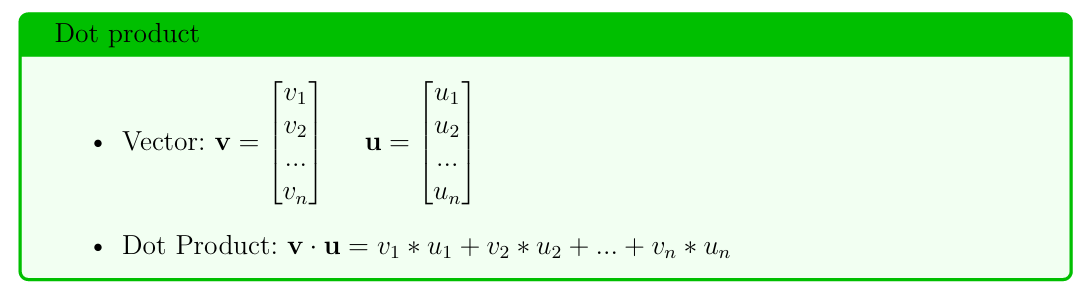

> Hàm compute_dot_product() sử dụng thư viện NumPy:

In [57]:
def compute_dot_product(vector1, vector2):
    result = 0
    for i in range(len(vector1)):
        result += vector1[i] * vector2[i]
    return result

v1 = np.array([0, 1,-1, 2])
v2 = np.array([2,5,1,0])
result = compute_dot_product(v1, v2)
print(round(result, 2))

4


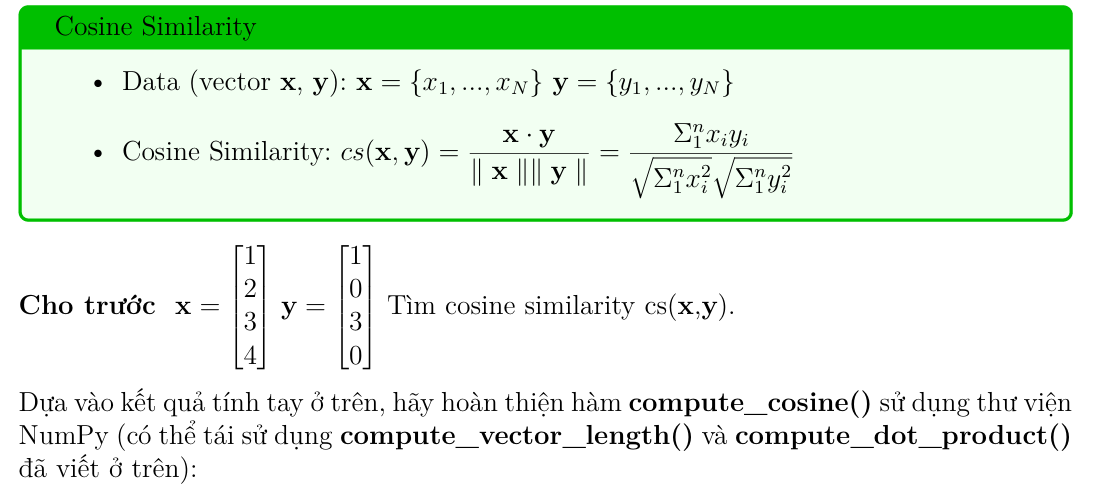

In [58]:
def compute_cosine(v1, v2):
  norm_v1 = compute_vector_length(v1)
  norm_v2 = compute_vector_length(v2)
  dot_product = compute_dot_product(v1, v2)
  return dot_product / (norm_v1 * norm_v2)

x = np.array([1, 2, 3, 4])
y = np.array([1, 0, 3, 0])

result = compute_cosine(v1, v2)
print(round(result, 3))

0.298


> **Cosine similarity với thư viện có sẵn (scipy):**

* Lưu ý rằng scipy.spatial.distance.cosine trả về cosine distance, tức là
1 − cosine similarity.

In [59]:
from scipy.spatial.distance import cosine

def compute_cosine_scipy(v1, v2):
  return 1 - cosine(v1, v2)
result = compute_cosine_scipy(x, y)
print(round(result, 3))


0.577


# Exercise 2
Chuyển ảnh màu sang ảnh xám (grayscale)

Ảnh màu thường được biểu diễn bằng ba kênh red, green, blue (RGB). Trong phần này, chúng ta sẽ chuyển ảnh màu sang ảnh xám (grayscale) bằng bốn phương pháp khác nhau, trong đó ba phương pháp đầu được cài đặt thủ công và phương pháp cuối sử dụng thư viện OpenCV.

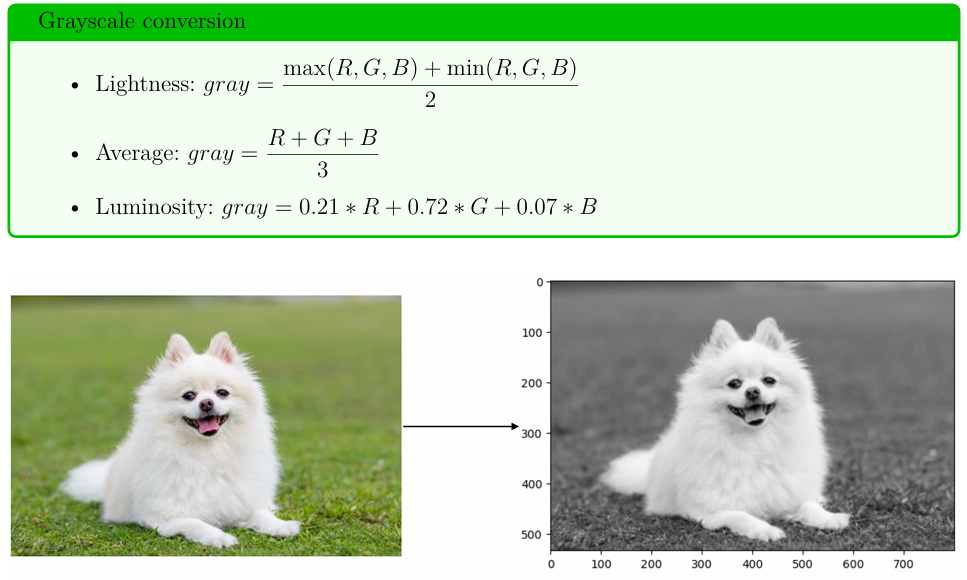

> **Step 1: Import libraries**

In [60]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def show_image(img, title=""):
  plt.imshow(img, cmap="gray")
  plt.title(title)
  plt.axis("off")
  plt.show()

> **Step 2: Download and load the image**

In [61]:
!gdown "https://drive.google.com/uc?id=1w4QKfXjLSRz1nEDQefSS3N_WG6nisdxS"

Downloading...
From: https://drive.google.com/uc?id=1w4QKfXjLSRz1nEDQefSS3N_WG6nisdxS
To: /content/Ảnh chụp màn hình 2026-07-24 003533.png
100% 158k/158k [00:00<00:00, 72.1MB/s]


In [62]:
img = mpimg.imread('/content/Ảnh chụp màn hình 2026-07-24 003533.png')
print(img.shape)

(265, 403, 4)


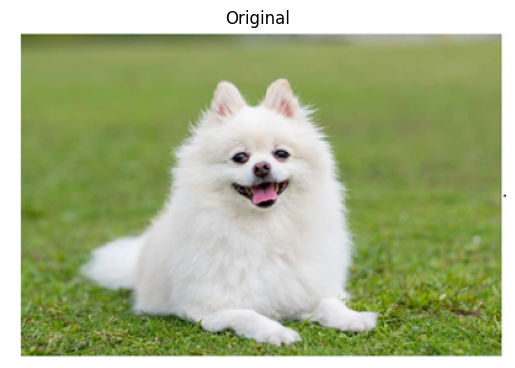

In [63]:
show_image(img, "Original")

> **Step 3: Implement grayscale conversion functions**

**Method 1: Lightness**

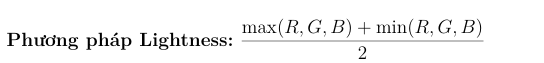

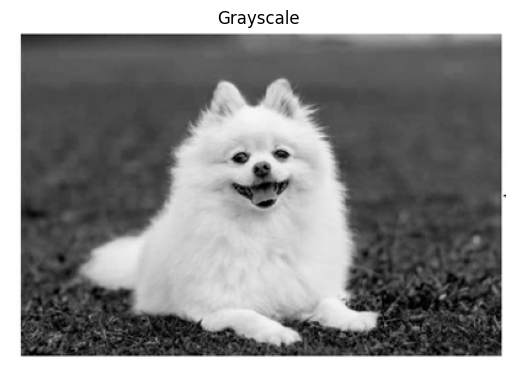

In [64]:
def to_gray_lightness(img):
  max_rgb = img.max(axis=2)
  min_rgb = img.min(axis=2)

  gray_img = ((max_rgb + min_rgb)/2)

  return gray_img

image_2 = to_gray_lightness(img)
show_image(image_2, "Grayscale")

**Method 2: Average**

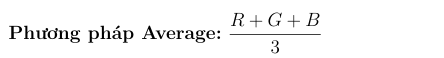

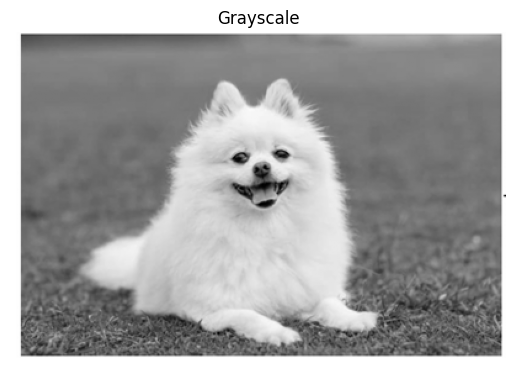

In [65]:
def to_gray_average(img):
  gray_img = np.mean(img, axis=2)

  return gray_img

show_image(to_gray_average(img), "Grayscale")

**Method 3: Luminosity**

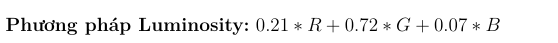

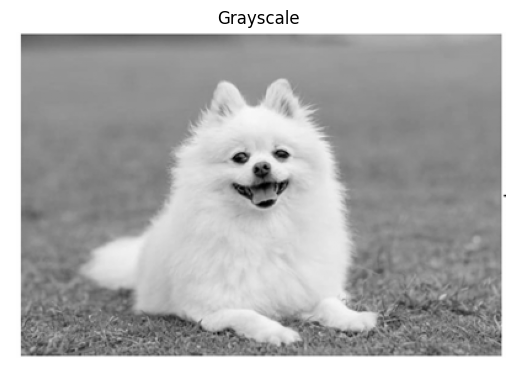

In [66]:
def to_gray_luminosity(img):
  R = img[:, :, 0]
  G = img[:, :, 1]
  B = img[:, :, 2]
  gray_img = 0.21*R + 0.72*G + 0.07*B

  return gray_img

show_image(to_gray_luminosity(img), "Grayscale")


**Method 4: Sử dụng thư viện (cv2.cvtColor): So sánh kết quả với hàm có sẵn của OpenCV**

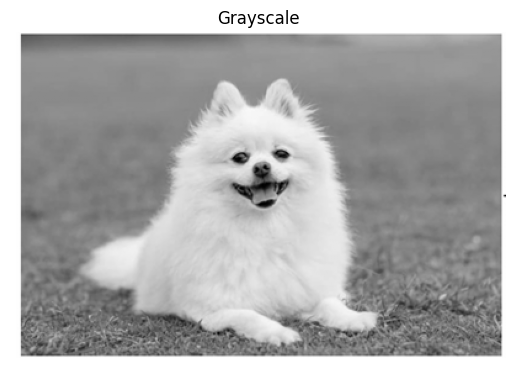

In [67]:
import cv2

def to_gray_cv2(img):
  gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  return gray_img

show_image(to_gray_cv2(img), "Grayscale")

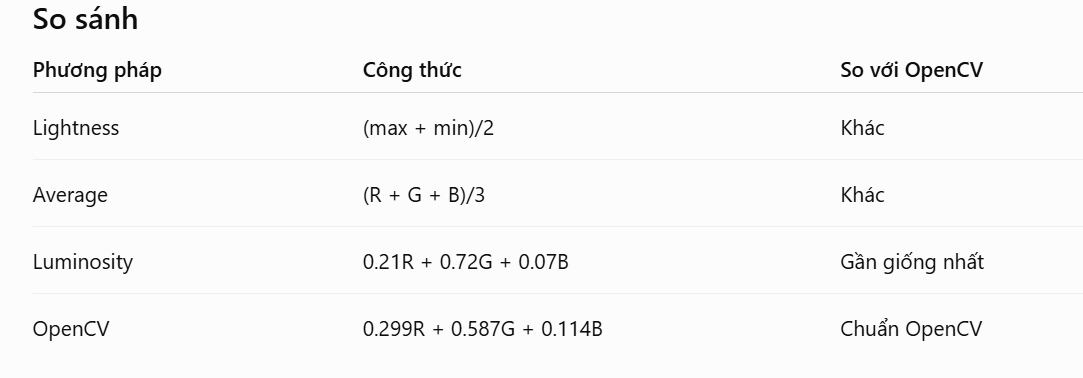

# Exercise 3: Background subtraction

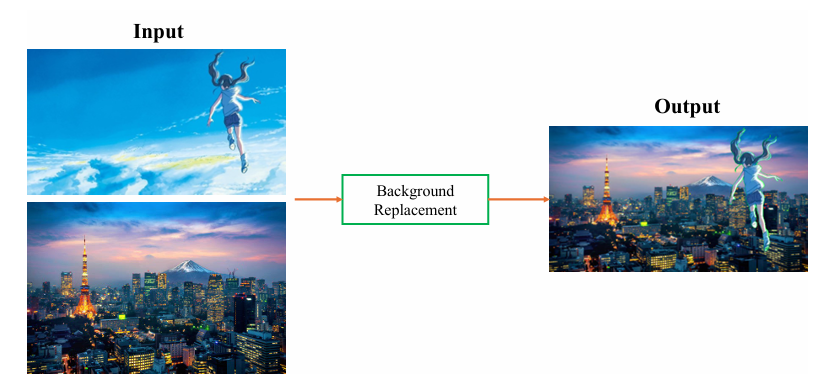

> **Step 1: Download and load the image**

In [68]:
!gdown --id 1pwTWcdkY3VOudV0rxKIPjue1DCC4j8W2 -O object_image.jpg

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1pwTWcdkY3VOudV0rxKIPjue1DCC4j8W2
To: /content/object_image.jpg
100% 51.0k/51.0k [00:00<00:00, 31.2MB/s]


In [69]:
!gdown --id 1gMinoV9tDStKXuUGpbI2h5S7wViw0AaK -O object_in_background_image.jpg

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1gMinoV9tDStKXuUGpbI2h5S7wViw0AaK
To: /content/object_in_background_image.jpg
100% 64.3k/64.3k [00:00<00:00, 116MB/s]


In [70]:
!gdown --id 12jWZPdhw4LDTMY9FNA5_HdFLc5SN65Rf -O background_image.jpg

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=12jWZPdhw4LDTMY9FNA5_HdFLc5SN65Rf
To: /content/background_image.jpg
100% 5.51k/5.51k [00:00<00:00, 17.4MB/s]


> **Step 2: Đọc và resize các ảnh đầu vào về cùng kích thước**

In [71]:
import cv2

ob_image = cv2.imread('/content/object.jpg', 1)
newbg = cv2.imread('/content/newbackground.jpg', 1)
bg_image = cv2.imread('/content/background_image.jpg', 1)
print(ob_image.shape)
print(newbg.shape)
print(bg_image.shape)

(381, 678, 3)
(408, 612, 3)
(381, 678, 3)


In [72]:
h, w = ob_image.shape[:2]
print(h, w)
newbg = cv2.resize(newbg, (w, h))

print(newbg.shape)
print(ob_image.shape)

381 678
(381, 678, 3)
(381, 678, 3)


> **Step 3: Compute different**

In [73]:
def compute_difference(bg_img, input_img):
  difference_three_channel = cv2.absdiff(bg_img, input_img)
  difference_single_channel = np.sum(difference_three_channel, axis = 2)
  difference_single_channel = difference_single_channel.astype('uint8')

  return difference_single_channel


In [74]:
from google.colab.patches import cv2_imshow

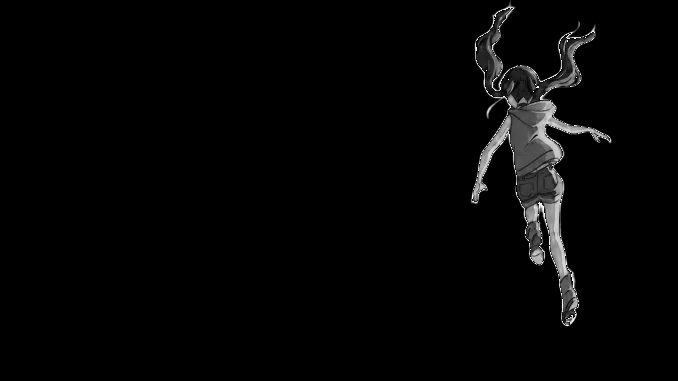

In [75]:
difference_single_channel = compute_difference(ob_image, bg_image)
cv2_imshow(difference_single_channel)

**Convert to binary image**

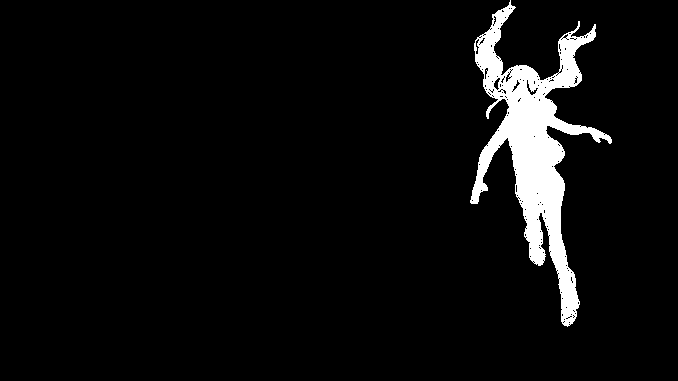

In [76]:
def compute_binary_mask(difference_single_channel):
  difference_binary = np.where(difference_single_channel >= 15, 255, 0)
  difference_binary = np.stack((difference_binary,)*3, axis = 2)

  return difference_binary


binary_mask = compute_binary_mask(difference_single_channel)
cv2_imshow(binary_mask)

**Replace background**

In [79]:
def replace_background(bg1_image, bg2_image, ob_image):
  difference_single_channel =  compute_difference(bg1_image, ob_image)
  binary_mask = compute_binary_mask(difference_single_channel)

  output = np.where(binary_mask == 255, ob_image, bg2_image)

  return output

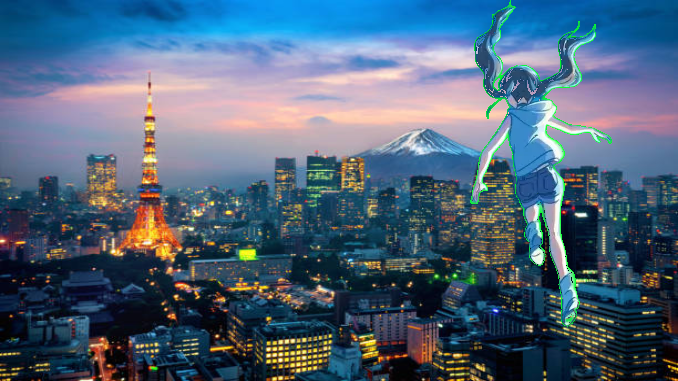

In [80]:
output = replace_background(bg_image, newbg, ob_image)
cv2_imshow(output)

# Exercise 4: Phân tích dữ liệu dạng bảng

Sử dụng NumPy kết hợp pandas để phân tích một dataset dạng bảng về chi phí quảng cáo (advertising). Dataset gồm bốn cột là TV, Radio, Newspaper (chi phí quảng cáo trên từng kênh) và Sales (doanh số).

Dataset advertising ghi lại chi phí quảng cáo của một sản phẩm trên ba kênh truyền thông là TV, radio và newspaper, cùng với doanh số (sales) tương ứng. Dataset gồm 200 mẫu (dòng) và 4 cột. Bảng 1 minh họa 5 mẫu đầu tiên của dataset

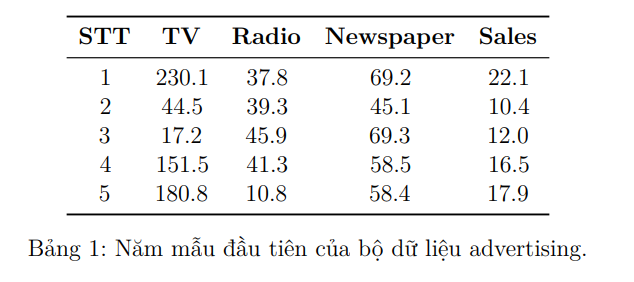

In [81]:
!gdown --id 1K7CO0Dwr92kdjjCWxgcQIOqFvELS11qH -O advertising.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1K7CO0Dwr92kdjjCWxgcQIOqFvELS11qH
To: /content/advertising.csv
100% 4.06k/4.06k [00:00<00:00, 10.8MB/s]


> **Trước tiên, dùng pandas để đọc file CSV và chuyển về mảng NumPy**

In [93]:
import pandas as pd

df = pd.read_csv('/content/advertising.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [94]:
type(df)

pandas.core.frame.DataFrame

> **Analayze the dataset**

In [92]:
data = df.to_numpy()
data[:5]

array([[230.1,  37.8,  69.2,  22.1],
       [ 44.5,  39.3,  45.1,  10.4],
       [ 17.2,  45.9,  69.3,  12. ],
       [151.5,  41.3,  58.5,  16.5],
       [180.8,  10.8,  58.4,  17.9]])

In [98]:
tv = data[:, 0]
radio = data[:, 1]
newspaper = data[:, 2]
sales = data[:, -1] # data[:, 3]

1. Tìm giá trị Sales lớn nhất và index của nó


In [100]:
max_value = np.max(sales)
max_index = np.argmax(sales)
print(f"Max: {max_value} - Index: {max_index}")


Max: 27.0 - Index: 175


2. Tính giá trị trung bình (mean) của cột TV

In [101]:
mean_tv = np.mean(tv)
print(mean_tv)

147.0425


3. Đếm số bản ghi có Sales ≥ 20

In [102]:
count = np.sum(sales >= 20)
print(count)

40


4. Tính mean của Radio tại những dòng có Sales lớn hơn giá trị trung bình

In [103]:
mean_radio = np.mean(radio[sales > np.mean(sales)])
print(mean_radio)

26.005607476635515


5. Tính tổng Sales tại những dòng có Newspaper lớn hơn giá trị trung bình

In [104]:
mean_newspaper = np.mean(newspaper)
sum_sales = np.sum(sales[newspaper > mean_newspaper])
print(sum_sales)

1405.1
